# Detecting drift

The forecasting model is trained on 2024. In 2025 the world changes. These are the true
events (the monitoring below does **not** know them):

In [1]:
import altair as alt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from river import drift
from scipy import stats

import inventory_data as d
from inventory_data import forecast, viz

alt.renderers.enable("png", scale_factor=2)  # static images: GitHub shows them
viz.enable()

In [2]:
events = d.drift_events()
events

,start,end,kind,event,stores,products
0,2025-01-15,NaN,concept drift,Fad diet: cucumber demand more than doubles (a...,all,102
1,2025-03-01,2025-08-31,sensor drift,Checkout scales in store 2 read a bit higher e...,2,kg items
2,2025-04-01,NaN,concept drift,A competitor opens next to store 3: 30 % less ...,3,all
3,2025-06-01,NaN,data drift,Two new stores open in Florida (much warmer cl...,"9, 10",all
4,2025-07-10,2025-07-31,data drift,Heatwave in PA and OH (+8 °C),1-8,all
5,2025-09-01,NaN,schema drift,POS software update in stores 7 and 8 records ...,"7, 8",kg items
6,2025-10-15,NaN,schema drift,The weather API changes temp_c from °C to °F (...,all,all


In [3]:
stores = d.drift_stores()
products = d.products()
data = forecast.features(d.drift_sales(), stores, d.drift_weather())
reference = data[data.date < "2025-01-01"]
model = forecast.train(reference)
live = data[data.date >= "2025-01-01"].assign(pred=lambda x: forecast.predict(model, x))

In [4]:
rules = (
    alt.Chart(events.assign(start=pd.to_datetime(events.start)))
    .mark_rule(color="#898781", strokeDash=[2, 2])
    .encode(x="start:T", tooltip=["start", "kind", "event"])
)

## 1. Data drift: compare input distributions with a reference

The temperature and the store of every row the model sees in a week of 2025 are compared
with the **same weeks of 2024** (± 2 weeks). A reference of the
whole year would report drift every summer: the temperature is seasonal. With thousands of
rows every p-value is tiny, so we look at the size of the difference (KS statistic, PSI).

In [5]:
def psi(ref: pd.Series, cur: pd.Series) -> float:
    cats = sorted(set(ref) | set(cur))
    p = ref.value_counts(normalize=True).reindex(cats, fill_value=0) + 1e-4
    q = cur.value_counts(normalize=True).reindex(cats, fill_value=0) + 1e-4
    return float(((q - p) * np.log(q / p)).sum())


rows = []
for week_start in pd.date_range("2025-01-06", "2025-12-22", freq="7D"):
    ref_start = week_start - pd.Timedelta(days=364 + 14)
    cur_sales = data[data.date.between(week_start, week_start + pd.Timedelta(days=6))]
    ref_sales = data[data.date.between(ref_start, ref_start + pd.Timedelta(days=34))]
    rows.append(
        {
            "week": week_start,
            "temperature (KS)": stats.ks_2samp(ref_sales.temp_c, cur_sales.temp_c).statistic,
            "temperature change (°C)": cur_sales.temp_c.mean() - ref_sales.temp_c.mean(),
            "temperature t-test p": stats.ttest_ind(
                ref_sales.temp_c, cur_sales.temp_c, equal_var=False
            ).pvalue,
            "store mix (PSI)": psi(ref_sales.store_id, cur_sales.store_id),
            "sales quantity (KS)": stats.ks_2samp(
                np.log1p(ref_sales.quantity), np.log1p(cur_sales.quantity)
            ).statistic,
        }
    )
weekly = pd.DataFrame(rows)

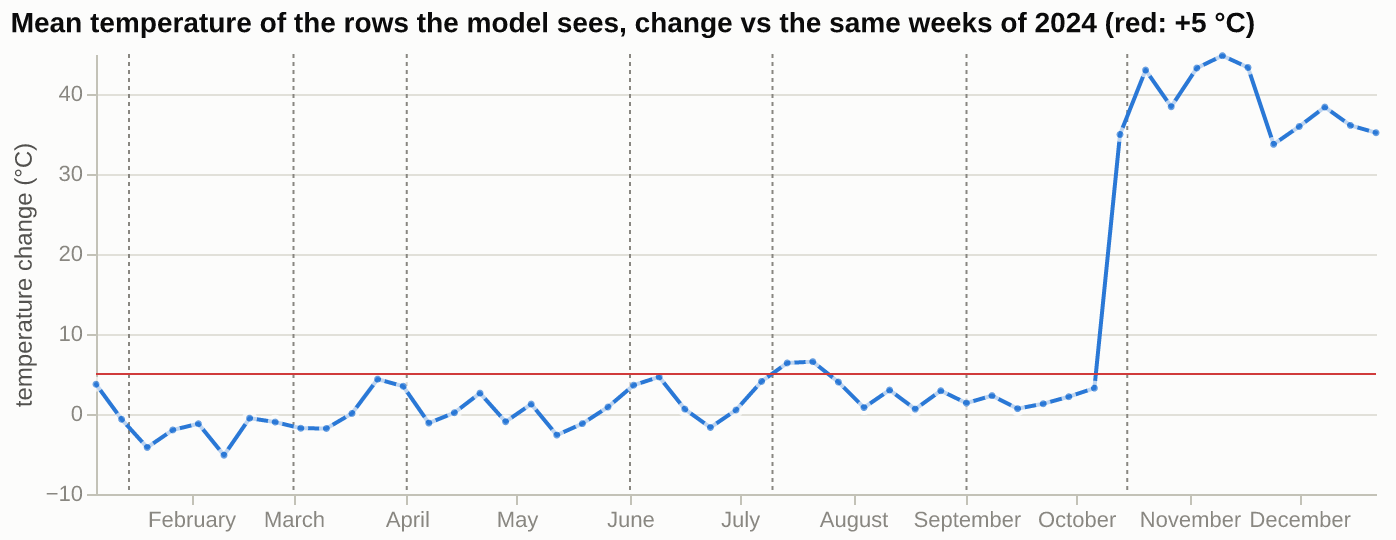

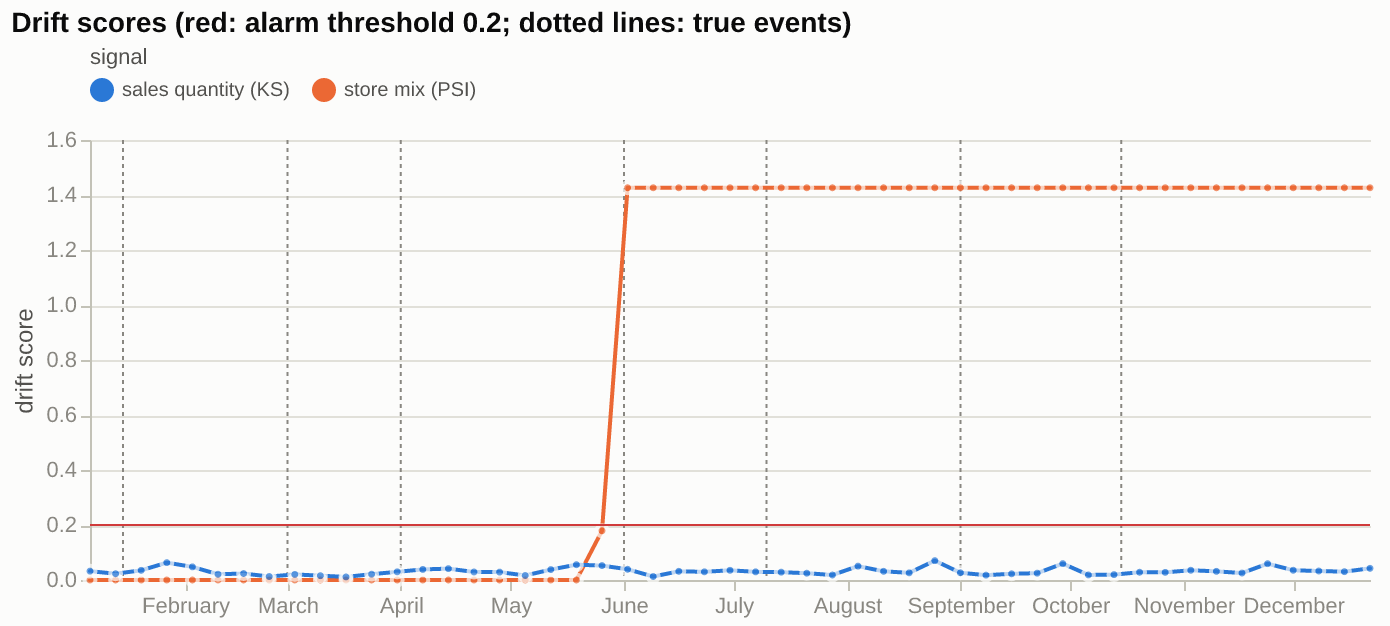

In [6]:
temp = alt.Chart(weekly).encode(
    x=alt.X("week:T", title=None),
    y=alt.Y("temperature change (°C):Q"),
    tooltip=[
        alt.Tooltip("week:T"),
        alt.Tooltip("temperature change (°C):Q", format=".1f"),
        alt.Tooltip("temperature (KS):Q", format=".2f"),
    ],
)
band = alt.Chart().mark_rule(color="#d03b3b", strokeWidth=1).encode(y=alt.datum(5))
long = weekly.melt(
    id_vars="week",
    value_vars=["store mix (PSI)", "sales quantity (KS)"],
    var_name="signal",
    value_name="drift score",
)
base = alt.Chart(long).encode(
    x=alt.X("week:T", title=None),
    y=alt.Y("drift score:Q"),
    color="signal:N",
    tooltip=[alt.Tooltip("week:T"), "signal", alt.Tooltip("drift score:Q", format=".3f")],
)
threshold = alt.Chart().mark_rule(color="#d03b3b", strokeWidth=1).encode(y=alt.datum(0.2))
display(
    (
        rules + temp.mark_line(color="#2a78d6") + temp.mark_point(size=30, color="#2a78d6") + band
    ).properties(
        width=640,
        height=220,
        title="Mean temperature of the rows the model "
        "sees, change vs the same weeks of 2024 (red: +5 °C)",
    )
)
display(
    (rules + base.mark_line() + base.mark_point(size=30) + threshold).properties(
        width=640,
        height=220,
        title="Drift scores (red: alarm threshold 0.2; dotted lines: true events)",
    )
)

The weather differs from year to year, so the temperature shifts by a few degrees without
any event (the KS statistic is between 0.2 and 0.7 in normal weeks). The heatwave, the new
stores in Florida, and the °F values stand out. The lb switch in two stores is almost
invisible in the distribution of all sales: a local change is diluted. With thousands of
rows, a t-test calls almost every week "significant":

In [7]:
weekly[["week", "temperature change (°C)", "temperature t-test p"]].head(6).assign(
    week=lambda w: w.week.dt.date,
    **{
        "temperature change (°C)": lambda w: w["temperature change (°C)"].round(1),
        "temperature t-test p": lambda w: w["temperature t-test p"].map("{:.1e}".format),
    },
)

,week,temperature change (°C),temperature t-test p
0,2025-01-06,3.7,0.0e+00
1,2025-01-13,-0.7,2.5e-29
2,2025-01-20,-4.2,0.0e+00
3,2025-01-27,-2.0,0.0e+00
4,2025-02-03,-1.2,3.3e-241
5,2025-02-10,-5.2,0.0e+00


## 2. Model degradation in telemetry: the actual sales arrive one day later

For every store and every product, the ratio *actual / predicted* per day is a stream. A
Page-Hinkley test (river) detects a sudden or gradual change of the mean of the stream.

In [8]:
ref_pred = reference.assign(pred=forecast.predict(model, reference))


def streams(df: pd.DataFrame, key: str) -> pd.DataFrame:
    g = df.groupby([key, "date"])[["quantity", "pred"]].sum()
    return (g.quantity / g.pred).rename("ratio").reset_index()


alarms = []
for key in ("store_id", "product_id"):
    ref_ratio = streams(ref_pred, key).groupby(key).ratio.std()
    for value, s in streams(live, key).groupby(key):
        sd = ref_ratio.get(value, s.ratio.std())
        ph = drift.PageHinkley(min_instances=14, delta=1.0, threshold=40, mode="both")
        for day, r in zip(s.date, s.ratio, strict=True):
            ph.update((r - 1) / max(sd, 0.02))
            if ph.drift_detected:
                alarms.append(
                    {
                        "stream": f"{key.removesuffix('_id')} {value}",
                        "date": day,
                        "mean ratio of the next 14 days": s[
                            s.date.between(day, day + pd.Timedelta(days=13))
                        ].ratio.mean(),
                    }
                )
alarms = pd.DataFrame(alarms)
daily = live.groupby("date")[["quantity", "pred"]].sum()
daily = (
    (np.abs(live.quantity - live.pred).groupby(live.date).sum() / daily.pred)
    .rename("WAPE")
    .reset_index()
)

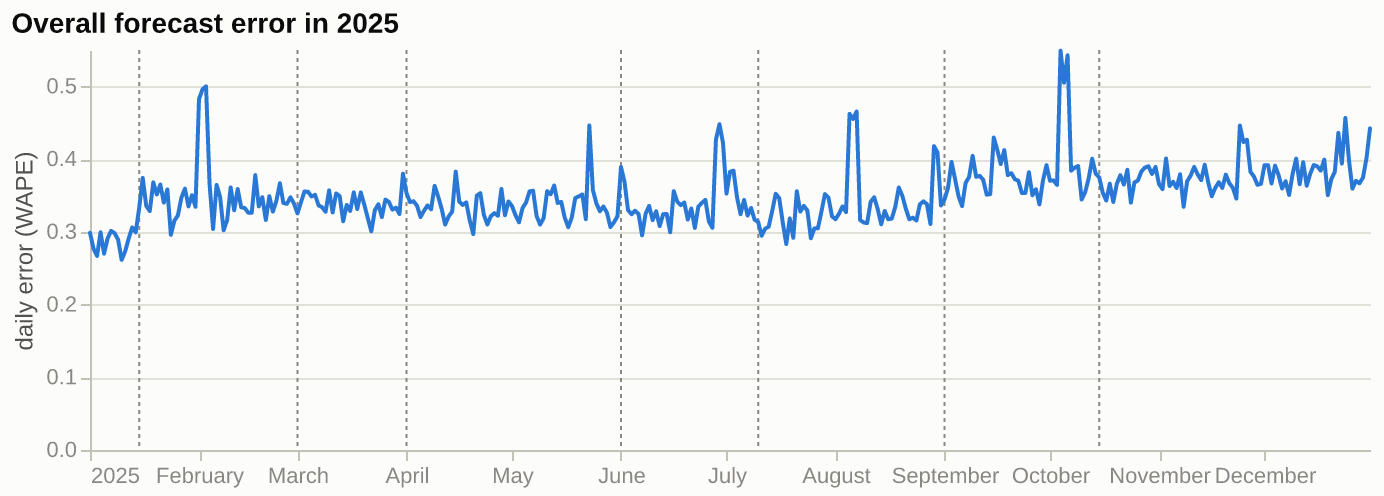

Streams with a Page-Hinkley alarm:

,alarms,first alarm
stream,,
product 102,2,2025-01-19
store 3,1,2025-04-09
store 7,1,2025-09-11
store 8,1,2025-09-12
product 159,1,2025-09-16
product 106,1,2025-09-17
product 127,1,2025-09-24
product 111,1,2025-09-25
product 110,1,2025-09-27


In [9]:
line = (
    alt.Chart(daily)
    .mark_line(color="#2a78d6")
    .encode(
        x=alt.X("date:T", title=None),
        y=alt.Y("WAPE:Q", title="daily error (WAPE)"),
        tooltip=[alt.Tooltip("date:T"), alt.Tooltip("WAPE:Q", format=".3f")],
    )
)
counts = (
    alarms.groupby("stream")
    .date.agg(["count", "min"])
    .rename(columns={"count": "alarms", "min": "first alarm"})
    .sort_values("first alarm")
)
display((rules + line).properties(width=640, height=200, title="Overall forecast error in 2025"))
display(Markdown("Streams with a Page-Hinkley alarm:"))
display(counts)

## 3. Where and when is the model wrong? (indicator of concept drift)

*Different outputs for similar inputs:* the ratio of actual to predicted sales by store and
month. Blue: the model predicts too much; red: too little.

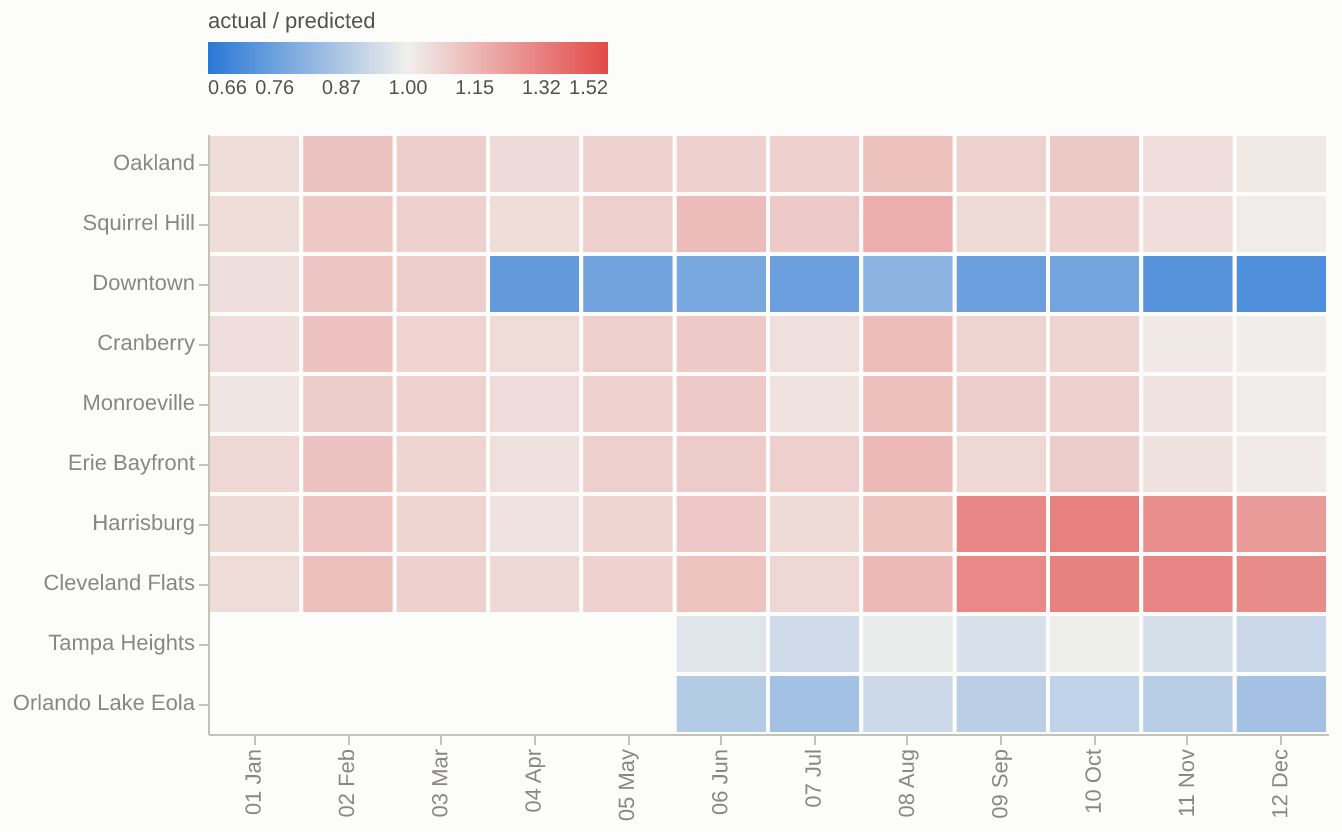

In [10]:
live_m = live.assign(month=live.date.dt.strftime("%m %b"))
g = live_m.groupby(["store_id", "month"])[["quantity", "pred"]].sum().reset_index()
g = g.assign(ratio=g.quantity / g.pred, log2_ratio=np.log2(g.quantity / g.pred))
g["store"] = g.store_id.map(stores.set_index("id").name)
heat = (
    alt.Chart(g)
    .mark_rect(stroke="#fcfcfb", strokeWidth=2)
    .encode(
        x=alt.X("month:O", title=None),
        y=alt.Y("store:N", title=None, sort=stores.name.tolist()),
        color=alt.Color(
            "log2_ratio:Q",
            title="actual / predicted",
            scale=alt.Scale(
                domain=[-0.6, 0, 0.6],
                range=["#2a78d6", "#f0efec", "#e34948"],
                clamp=True,
                interpolate="rgb",
            ),
            legend=alt.Legend(format=".1f", labelExpr="format(pow(2, datum.value), '.2f')"),
        ),
        tooltip=["store", "month", alt.Tooltip("ratio:Q", format=".2f")],
    )
)
heat.properties(width=560, height=300)

Same inputs, different outputs: the concept changed.

In [11]:
def similar_inputs(df, **where):
    rows = df
    for k, v in where.items():
        rows = rows[rows[k] == v]
    return rows


cuc = similar_inputs(live, product_id=102, promo=0)
comp = similar_inputs(live, store_id=3, promo=0)
table = pd.DataFrame(
    {
        "segment": ["cucumbers, no promotion", "store 3, no promotion"],
        "actual / predicted before": [
            cuc[cuc.date < "2025-01-15"].quantity.sum() / cuc[cuc.date < "2025-01-15"].pred.sum(),
            comp[comp.date < "2025-04-01"].quantity.sum()
            / comp[comp.date < "2025-04-01"].pred.sum(),
        ],
        "actual / predicted after": [
            cuc[cuc.date >= "2025-02-01"].quantity.sum() / cuc[cuc.date >= "2025-02-01"].pred.sum(),
            comp[comp.date >= "2025-04-15"].quantity.sum()
            / comp[comp.date >= "2025-04-15"].pred.sum(),
        ],
    }
).round(2)
table

,segment,actual / predicted before,actual / predicted after
0,"cucumbers, no promotion",1.00,2.09
1,"store 3, no promotion",1.08,0.76


## 4. Gradual drift of a sensor: CUSUM vs a fixed threshold

The average weight per banana line at the checkout of each store. In store 2 the scales
read a little higher every day. A 3-sigma rule sees only large jumps; a CUSUM detector
adds up small deviations and alarms much earlier.

In [12]:
scale = d.drift_scale_readings().query("store_id == 2 and date < '2025-09-01'")
ref_s = scale[scale.date < "2025-01-01"].mean_banana_line_kg
z = ((scale.mean_banana_line_kg - ref_s.mean()) / ref_s.std()).to_numpy()
cusum = np.zeros(len(z))
for i in range(1, len(z)):
    cusum[i] = max(0.0, cusum[i - 1] + z[i] - 0.5)
scale = scale.assign(z=z, cusum=cusum)
live_s = scale[scale.date >= "2025-01-01"]
first = {
    "3-sigma rule": live_s.date[live_s.z > 3].min(),
    "CUSUM (k = 0.5, h = 5)": live_s.date[live_s.cusum > 5].min(),
}
detect = pd.DataFrame(
    {
        "first alarm": {k: v.date() for k, v in first.items()},
        "days after the drift started (2025-03-01)": {
            k: (v - pd.Timestamp("2025-03-01")).days for k, v in first.items()
        },
    }
)

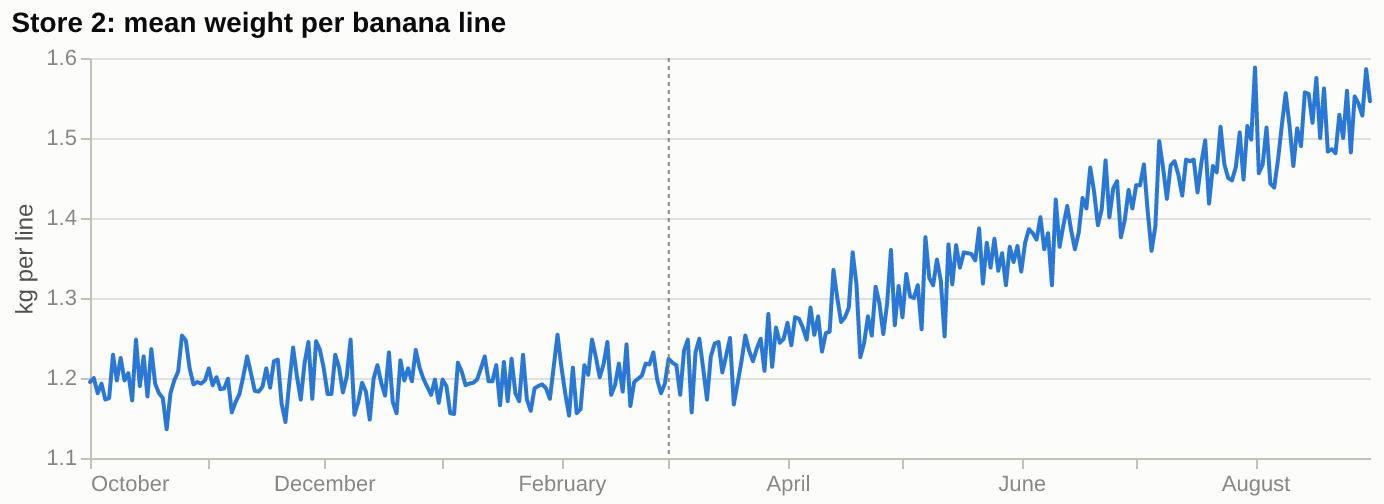

,first alarm,days after the drift started (2025-03-01)
3-sigma rule,2025-03-27,26
"CUSUM (k = 0.5, h = 5)",2025-03-17,16


In [13]:
recent = scale[scale.date >= "2024-10-01"]
line = (
    alt.Chart(recent)
    .mark_line(color="#2a78d6")
    .encode(
        x=alt.X("date:T", title=None),
        y=alt.Y("mean_banana_line_kg:Q", title="kg per line", scale=alt.Scale(zero=False)),
        tooltip=[alt.Tooltip("date:T"), alt.Tooltip("mean_banana_line_kg:Q", format=".3f")],
    )
)
drift_start = (
    alt.Chart()
    .mark_rule(color="#898781", strokeDash=[2, 2])
    .encode(x=alt.datum(alt.DateTime(year=2025, month=3, date=1)))
)
display(
    (line + drift_start).properties(
        width=640, height=200, title="Store 2: mean weight per banana line"
    )
)
display(detect)

## 5. Schema drift: a validation rule sees it at once

The weather API starts to report °F in the column `temp_c`. A plain range check (−30 to
45 °C) fails on the first day. The switch of the POS systems to lb is harder: the values
stay plausible, so only the distribution checks and the error streams of stores 7 and 8
above find it.

In [14]:
wx_api = d.drift_weather()
invalid = wx_api[~wx_api.temp_c.between(-30, 45)].groupby("date").size()
first_invalid = invalid.index.min()
print("first day with an invalid temperature:", pd.Timestamp(first_invalid).date())

first day with an invalid temperature: 2025-10-15


## Summary: detection delay per event

In [15]:
def first_after(stream_prefix: str, start: str) -> str:
    a = alarms[alarms.stream.str.startswith(stream_prefix) & (alarms.date >= start)]
    a = a[a.date <= pd.Timestamp(start) + pd.Timedelta(days=60)]
    return "not found" if a.empty else f"{(a.date.min() - pd.Timestamp(start)).days} days"


summary = pd.DataFrame(
    [
        (
            "fad diet (cucumbers)",
            "Page-Hinkley on product 102",
            first_after("product 102", "2025-01-15"),
        ),
        ("scale drift store 2", "CUSUM on scale readings", f"{detect.iloc[1, 1]} days"),
        (
            "competitor near store 3",
            "Page-Hinkley on store 3",
            first_after("store 3", "2025-04-01"),
        ),
        ("POS in lb, store 7", "Page-Hinkley on store 7", first_after("store 7", "2025-09-01")),
        ("POS in lb, store 8", "Page-Hinkley on store 8", first_after("store 8", "2025-09-01")),
        ("weather API in °F", "range check on temp_c", "0 days"),
    ],
    columns=["event", "detector", "detection delay"],
)
display(summary)
display(
    Markdown(
        f"Page-Hinkley raised {len(alarms)} alarms on {alarms.stream.nunique()} streams in "
        "total. Not every alarm is an event: a monitoring threshold trades early detection for "
        "false alarms."
    )
)

,event,detector,detection delay
0,fad diet (cucumbers),Page-Hinkley on product 102,4 days
1,scale drift store 2,CUSUM on scale readings,16 days
2,competitor near store 3,Page-Hinkley on store 3,8 days
3,"POS in lb, store 7",Page-Hinkley on store 7,10 days
4,"POS in lb, store 8",Page-Hinkley on store 8,11 days
5,weather API in °F,range check on temp_c,0 days


Page-Hinkley raised 21 alarms on 20 streams in total. Not every alarm is an event: a monitoring threshold trades early detection for false alarms.